In [2]:
import sys
sys.path.append("/user/christoph.wald/u15287/insect_pest_detection/modules")
import cv2
import matplotlib.pyplot as plt
from modules_segmentation import *
import random

### Load empty image

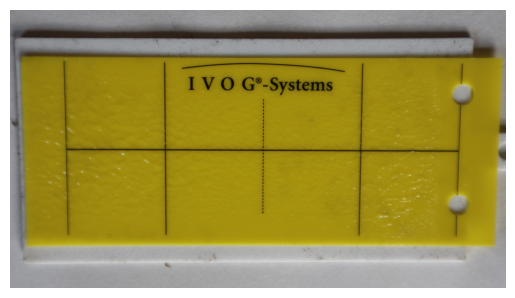

In [2]:
image_folder = "/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST"
empty_YST = cv2.imread("/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST/IMG_5885.JPG")
rgb_image = cv2.cvtColor(empty_YST, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

### Use "direct" mask...

using only simple binarization.


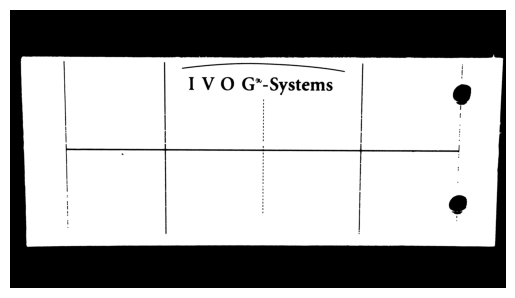

In [3]:
mask = create_binary_mask(empty_YST)
cleaned_mask = denoise_mask(mask)
rgb_image = cv2.cvtColor(cleaned_mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

### .... or the one used for segmenting?

In [64]:
processed_mask = cv2.imread(
    "/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/06_generated_mask_fat_plus.jpg", 
    cv2.IMREAD_GRAYSCALE
)

gridcorners = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/gridcorners.npy")
mask_h_line = np.load("/user/christoph.wald/u15287/insect_pest_detection/2_4_image_processing/masks/mask_h_line.npy")

image_files = os.listdir(image_folder)

def get_mask(image_file):
    #Load image file
    print(f"Loading {image_file}")
    image = cv2.imread(os.path.join(image_folder, image_file))

    #find YST contour of image
    imageYST = find_contour(image)

    #save cropped image
    x, y, w, h = cv2.boundingRect(imageYST)
    

    #find corners if possible, if not skip the image
    imagecorners = find_corners(image, imageYST)
    if len(imagecorners) == 0:
        print(f"No YST found for {image_file}")
        return None

    #find transformation
    H, _ = cv2.findHomography(gridcorners, imagecorners, cv2.RANSAC)

    #first transformation: 
    mask = cv2.warpPerspective(processed_mask, H, (image.shape[1], image.shape[0]))
    
    #transform midline of mask as above
    h_line_pts = mask_h_line.reshape(-1,1,2)
    h_line_pts_warped = cv2.perspectiveTransform(h_line_pts, H)
    x1w, y1w, x2w, y2w = h_line_pts_warped.reshape(-1).astype(np.int32)
    mask_h = (x1w, y1w, x2w, y2w)

    #second transformation: correct vertical misalignment
    image_h = get_h_mid(create_binary_mask(image))
    dy = get_midpoint(image_h)- get_midpoint(mask_h)
    print (dy)
    if abs(dy) > 500:
        print(f"Skipped vertical alignment, wrong horizontal line with offset {dy}")
    else:
        H, W = mask.shape[:2]
        M = np.float32([[1, 0, 0], [0, 1, dy]])  # translation matrix
        mask= cv2.warpAffine(mask, M, (W, H), borderValue=255)  # white background
    return mask[y:y+h, x:x+w]

Loading IMG_5885.JPG
using only simple binarization.
using only simple binarization.
0.0


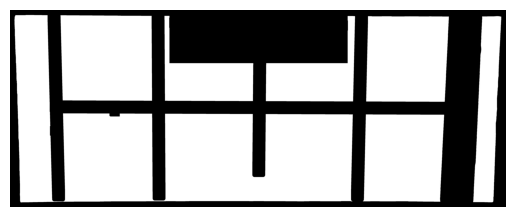

In [65]:
fat_mask = get_mask("IMG_5885.JPG")
rgb_image = cv2.cvtColor(fat_mask, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()

### find some insects

In [66]:
def enlarge_box(box, image_shape, scale=0.2):
    """
    Enlarge a bounding box by a given percentage.

    Parameters:
        box (tuple): (x1, y1, x2, y2)
        image_shape (tuple): (height, width, channels) of the image
        scale (float): Fraction to enlarge the box (e.g., 0.2 = 20%)

    Returns:
        tuple: New enlarged box (x1_new, y1_new, x2_new, y2_new)
    """
    x1, y1, x2, y2 = box
    width = x2 - x1
    height = y2 - y1

    # Amount to expand
    dx = int(width * scale / 2)
    dy = int(height * scale / 2)

    # New coordinates
    x1_new = max(x1 - dx, 0)
    y1_new = max(y1 - dy, 0)
    x2_new = min(x2 + dx, image_shape[1] - 1)
    y2_new = min(y2 + dy, image_shape[0] - 1)

    return (x1_new, y1_new, x2_new, y2_new)

In [68]:
#load image file
images_masked = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/03_images_masked"
file_list = os.listdir(images_masked)
image_file = random.choice(file_list)#
print(image_file)

image_masked = cv2.imread(os.path.join(images_masked, image_file))

    
#recangles
if "TRIAVA" in image_file:
    min_area_contour = 100 
    max_area_contour = 2000
    scale = 1.5
    max_ratio = 2 
    upper_limit_rectangles = None
    value_threshold =97 # 5th percentile
    binary_default = False
elif "LIRIBO" in image_file: 
    min_area_contour = 1000 
    max_area_contour = 10000 
    scale = 1.5
    max_ratio = 1.76 #95th percentile
    upper_limit_rectangles = 28530 #22340 #95th percentile
    value_threshold = None
    binary_default = True
elif "BRAIIM" in image_file:
    min_area_contour = 2000 
    max_area_contour = 10000
    scale = 1.5
    max_ratio = 1.73 #1.75 #95the percentile
    upper_limit_rectangles = 42970 #41703 #95th percentil
    value_threshold = None
    binary_default = True

rectangles, v = get_list_of_rectangles(image_masked, min_area_contour, max_area_contour, scale, max_ratio, upper_limit_rectangles, value_threshold, binary_default)

if "TRIAVA" in image_file:
    rectangles = remove_smaller_overlaps(rectangles)

#convert xywh -> xyxy
rectangles = [(x, y, x + w, y + h) for (x, y, w, h) in rectangles]
print(len(rectangles))

LIRIBO_0676.jpg
using only simple binarization.
8


In [69]:
scale = 1
rectangles = [enlarge_box(box, image.shape, scale) for box in rectangles]

In [70]:
images_folder = "/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/SSL/04_images_cropped" 
image = cv2.imread(os.path.join(images_folder, image_file))
hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
insects = []
for box in rectangles:
    x1, y1, x2, y2 = map(int, box)
    region_bgr = image[y1:y2, x1:x2]
    region_hsv = hsv_image[y1:y2, x1:x2]
    #plt.imshow(cv2.cvtColor(region_bgr, cv2.COLOR_BGR2RGB))
    #plt.axis("off")
    #plt.show()
    value = region_hsv[:, :, 2]
    # --- Otsu threshold ---
    otsu_thresh, binary_mask = cv2.threshold(value, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    #plt.imshow(binary_mask, cmap= "gray")
    #plt.axis("off")
    #plt.show()
    binary_mask_inv = cv2.bitwise_not(binary_mask)  # foreground=255, background=0
    # Apply mask to the region_bgr
    foreground = cv2.bitwise_and(region_bgr, region_bgr, mask=binary_mask_inv)

    # Optional: set background to white
    background = np.full_like(region_bgr, 255)  # white background
    result = np.where(binary_mask_inv[:, :, np.newaxis] == 0, background, foreground)
    insects.append(result)
    # Show result
    #plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
    #plt.axis("off")
    #plt.show()

In [71]:
len(insects)

8

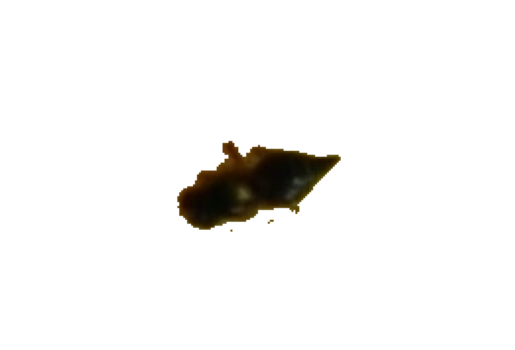

In [72]:
plt.imshow(cv2.cvtColor(insects[3], cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

using only simple binarization.
Cropped empty YST shape: (2318, 5835, 3)
Successfully placed 8/8 insects.


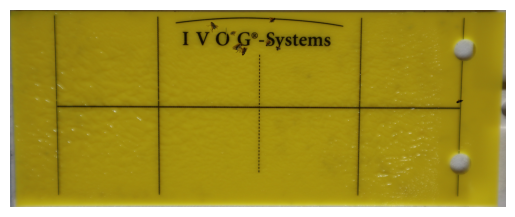

In [ ]:
# Convert mask to binary (assuming 255 = valid area, 0 = invalid)
#mask_binary = (processed_mask > 127).astype(np.uint8)
#it is the other way round
mask_binary = (fat_mask < 128).astype(np.uint8)


empty_YST = cv2.imread("/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST/IMG_5885.JPG")
imageYST = find_contour(empty_YST)
x, y, w, h = cv2.boundingRect(imageYST)

# Crop image and mask to the YST region
empty_YST_cropped = empty_YST[y:y+h, x:x+w]
h_img, w_img, _ = empty_YST_cropped.shape
print("Cropped empty YST shape:", empty_YST_cropped.shape)

def place_insect(base, mask, insect, min_mask_overlap=0.8, max_attempts=1000):
    """Randomly place one insect on base image with mask constraint."""
    h_insect, w_insect, _ = insect.shape

    for _ in range(max_attempts):
        # Random top-left position
        x = random.randint(0, w_img - w_insect)
        y = random.randint(0, h_img - h_insect)

        # Crop mask region where insect would be placed
        mask_region = mask[y:y+h_insect, x:x+w_insect]

        # Compute proportion of valid (mask=1) pixels
        overlap_ratio = np.mean(mask_region)

        if overlap_ratio >= min_mask_overlap:
            # Paste insect on the base image
            insect_gray = cv2.cvtColor(insect, cv2.COLOR_BGR2GRAY)
            alpha_mask = (insect_gray < 250).astype(np.uint8)  # non-white = foreground
            alpha_mask_3d = np.repeat(alpha_mask[:, :, None], 3, axis=2)

            # Combine images
            region = base[y:y+h_insect, x:x+w_insect]
            blended = np.where(alpha_mask_3d == 1, insect, region)
            base[y:y+h_insect, x:x+w_insect] = blended
            return True
    return False

def place_insect_efficient(base_image, mask_binary, insect, min_mask_overlap=0.8):
    h_img, w_img, _ = base_image.shape
    h_insect, w_insect, _ = insect.shape

    # Find all valid pixels
    valid_coords = np.argwhere(mask_binary == 1)  # (y, x) format
    if len(valid_coords) == 0:
        return False  # no valid placement possible

    for _ in range(1000):  # try up to 1000 positions
        # Randomly pick one valid pixel as top-left
        y, x = valid_coords[np.random.randint(len(valid_coords))]

        # Ensure insect fits in image boundaries
        if x + w_insect > w_img or y + h_insect > h_img:
            continue

        # Crop mask region for overlap check
        mask_region = mask_binary[y:y+h_insect, x:x+w_insect]
        overlap_ratio = np.mean(mask_region)

        if overlap_ratio >= min_mask_overlap:
            # Paste insect
            alpha_mask = (cv2.cvtColor(insect, cv2.COLOR_BGR2GRAY) < 200).astype(np.uint8)
            alpha_mask_3d = np.repeat(alpha_mask[:, :, None], 3, axis=2)
            region = base_image[y:y+h_insect, x:x+w_insect]
            blended = np.where(alpha_mask_3d == 1, insect, region)
            base_image[y:y+h_insect, x:x+w_insect] = blended
            return True

    return False  # failed to place


# --- Place insects ---
placed_count = 0
for insect in insects:
    success = place_insect_efficient(empty_YST_cropped, mask_binary, insect)
    if success:
        placed_count += 1

print(f"Successfully placed {placed_count}/{len(insects)} insects.")

# Show result
cv2.imwrite("test.jpg", empty_YST_cropped)
rgb_image = cv2.cvtColor(empty_YST_cropped, cv2.COLOR_BGR2RGB)
plt.imshow(rgb_image)
plt.axis("off")
plt.show()


### The other idea: Place background behind existing tiles

In [7]:
def create_binary_mask_strong(image, binary_default=True):
    '''
    Binary masking with manual threshold (yellow)
    '''
    if binary_default:
        lower_yellow = np.array([20, 120, 120])
        upper_yellow = np.array([30, 255, 255])
        hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
        mask = cv2.inRange(hsv, lower_yellow, upper_yellow)
        return mask
def crop(image):
    mask = create_binary_mask(image)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        cropped_image = image[y:y+h, x:x+w]
        return cropped_image, (x, y, w, h)
    else:
        return None, None
    
def show(img, title = None):
    '''
    plot an an cv2 image
    for use in notebooks
    '''
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.axis('off')
    if title: plt.title(title) 
    plt.show()

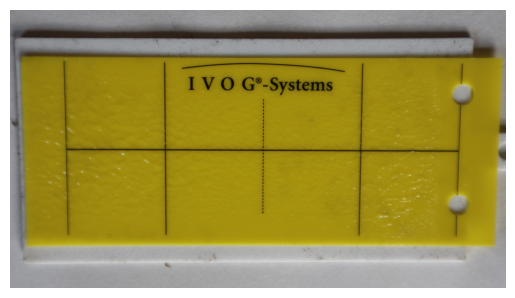

using only simple binarization.


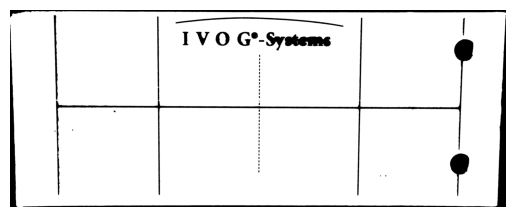

In [8]:
image_folder = "/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST"
empty_YST = cv2.imread("/user/christoph.wald/u15287/big-scratch/00_uncropped_dataset/emptyYST/IMG_5885.JPG")
show(empty_YST)
empty_YST, _ = crop(empty_YST)
mask = create_binary_mask_strong(empty_YST)
cleaned_mask = denoise_mask(mask)
show(cleaned_mask)

In [9]:
import cv2
import numpy as np

edges = cv2.Canny(mask, 50, 150)
lines = cv2.HoughLinesP(edges, 1, np.pi/180, threshold=100, minLineLength=50, maxLineGap=10)


In [10]:
empty_YST.shape

(2318, 5835, 3)

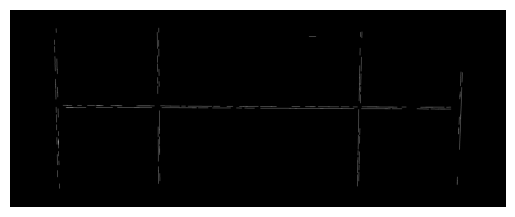

In [11]:
import cv2
import numpy as np

height, width, _ = empty_YST.shape
margin = 200  # pixels from the edge

filtered_lines = []

for line in lines:
    x1, y1, x2, y2 = line[0]  # HoughLinesP format
    
    # Keep only lines fully inside the image, ignoring a margin
    if (x1 >= margin and x1 <= width - margin and
        x2 >= margin and x2 <= width - margin and
        y1 >= margin and y1 <= height - margin and
        y2 >= margin and y2 <= height - margin):
        filtered_lines.append(line)

# Now draw only the filtered lines
blank_img = np.zeros((height, width), dtype=np.uint8)
for line in filtered_lines:
    x1, y1, x2, y2 = line[0]
    cv2.line(blank_img, (x1, y1), (x2, y2), color=255, thickness=2)

    
show(blank_img)


In [12]:
lines = filtered_lines

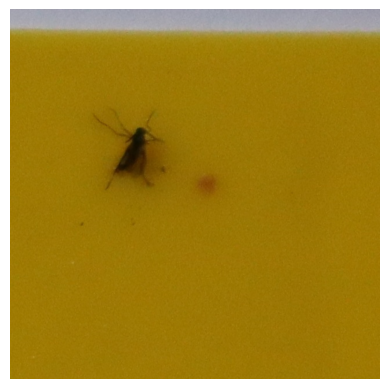

In [13]:
tile = cv2.imread("/user/christoph.wald/u15287/big-scratch/02_splitted_data/train_labeled/tiles/train/images/BRAIIM_0003_tile_10.jpg")
cv2.imwrite("tile.jpg", tile)
show(tile)


159 183 269 312


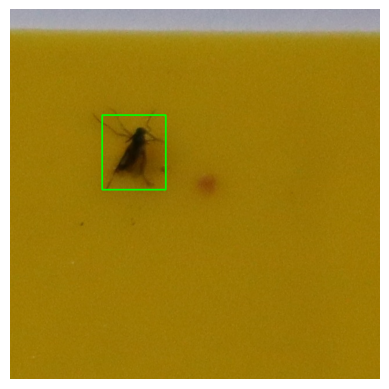

In [14]:
img_w, img_h = 640, 640
l = [0, 0.335156, 0.386719, 0.170313, 0.201563]

x_center = l[1] * img_w
y_center = l[2] * img_h
w = l[3] * img_w
h = l[4] * img_h

x1 = int(x_center - w/2)
y1 = int(y_center - h/2)
x2 = int(x_center + w/2)
y2 = int(y_center + h/2)

print(x1, y1, x2, y2)

tile_copy = tile.copy()
show(cv2.rectangle(tile_copy, (x1,y1), (x2,y2), color = (0,255,0), thickness=2))

In [15]:
# Assume we pick the first line for simplicity
line = lines[0][0]  # (x1, y1, x2, y2)

# Compute line center
line_center = ((line[0]+line[2])//2, (line[1]+line[3])//2)

# Compute box center
box_center = ((x1+x2)//2, (y1+y2)//2)

# Compute shift needed
shift_x = box_center[0] - line_center[0]
shift_y = box_center[1] - line_center[1]

# Shift large_img
M = np.float32([[1, 0, shift_x], [0, 1, shift_y]])
shifted_large = cv2.warpAffine(empty_YST, M, (empty_YST.shape[1], empty_YST.shape[0]))
shifted_binary = cv2.warpAffine(cleaned_mask, M, (cleaned_mask.shape[1], cleaned_mask.shape[0]))


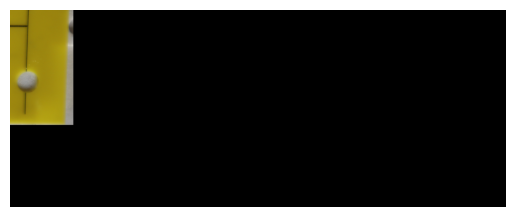

In [16]:
show(shifted_large)

In [17]:
h, w = tile.shape[:2]
start_x = max(0, box_center[0] - w//2)
start_y = max(0, box_center[1] - h//2)

patch_color = shifted_large[start_y:start_y+h, start_x:start_x+w]
patch_binary = shifted_binary[start_y:start_y+h, start_x:start_x+w]


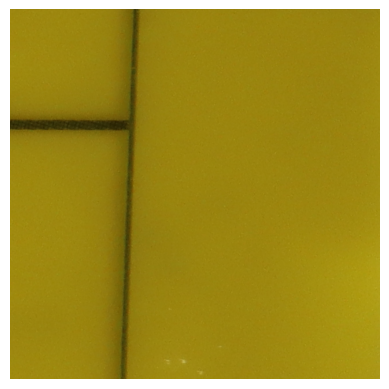

True

In [18]:
show(patch_color)
cv2.imwrite("background_tile.jpg", patch_color)

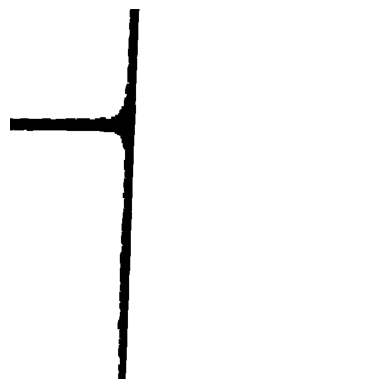

In [19]:
show(patch_binary)

using only simple binarization.


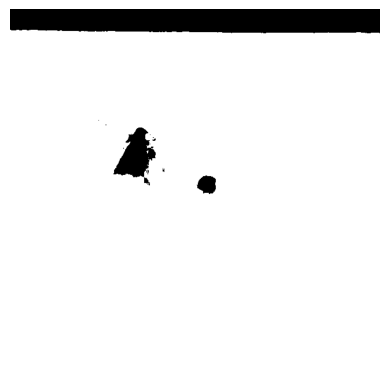

In [20]:
yellow_mask = create_binary_mask(tile)  # 255 = yellow background
yellow_mask_3c = cv2.merge([yellow_mask//255]*3)
show(yellow_mask)

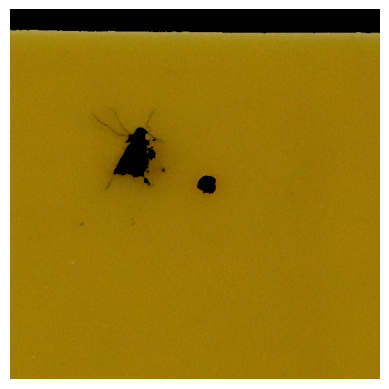

In [21]:
background_layer = tile.copy()
background_layer[yellow_mask_3c == 0] = 0  # keep only yellow background
show(background_layer)

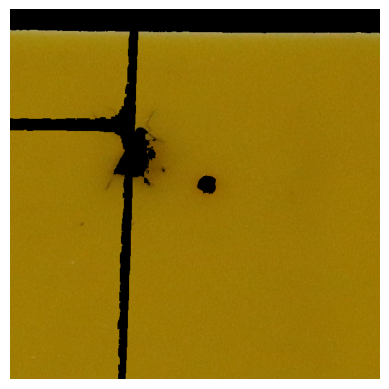

In [22]:
line_mask = (patch_binary == 255).astype(np.uint8)
line_mask_3c = cv2.merge([line_mask]*3)
merged = background_layer.copy()

# Overlay the black lines where line_mask_3c == 1
merged[line_mask_3c == 0] = 0
show(merged)

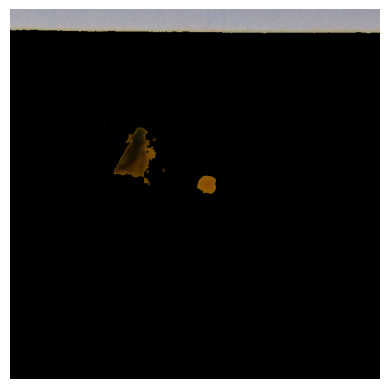

In [23]:
foreground_layer = np.zeros_like(tile)
foreground_layer[yellow_mask_3c == 0] = tile[yellow_mask_3c == 0]
show(foreground_layer)

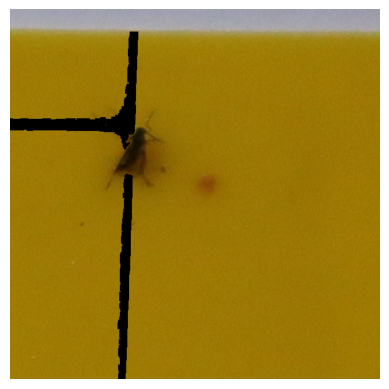

In [25]:
merged[yellow_mask_3c == 0] = tile[yellow_mask_3c == 0]
cv2.imwrite("new_tile.jpg", merged)
show(merged)